# **0. Datasets Loading**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

telemetry = pd.read_csv(r'DataSet\PdM_telemetry.csv')
errors = pd.read_csv(r'DataSet\PdM_errors.csv')
maint = pd.read_csv(r'DataSet\PdM_maint.csv')
failures = pd.read_csv(r'DataSet\PdM_failures.csv')
machines = pd.read_csv(r'DataSet\PdM_machines.csv')

### **summarize**

- Telemetry Time Series Data (PdM_telemetry.csv): It consists of hourly average of voltage, rotation, pressure, vibration collected from 100 machines for the year 2015.

- Error (PdM_errors.csv): These are errors encountered by the machines while in operating condition. Since, these errors don't shut down the machines, these are not considered as failures. The error date and times are rounded to the closest hour since the telemetry data is collected at an hourly rate.

- Maintenance (PdM_maint.csv): If a component of a machine is replaced, that is captured as a record in this table. Components are replaced under two situations: 1. During the regular scheduled visit, the technician replaced it (Proactive Maintenance) 2. A component breaks down and then the technician does an unscheduled maintenance to replace the component (Reactive Maintenance). This is considered as a failure and corresponding data is captured under Failures. Maintenance data has both 2014 and 2015 records. This data is rounded to the closest hour since the telemetry data is collected at an hourly rate.

- Failures (PdM_failures.csv): Each record represents replacement of a component due to failure. This data is a subset of Maintenance data. This data is rounded to the closest hour since the telemetry data is collected at an hourly rate.

- Metadata of Machines (PdM_Machines.csv): Model type & age of the Machines.

# **1. Preprocessing**

### **Change date to datetime & Data information**

In [2]:
telemetry['datetime'] = pd.to_datetime(telemetry['datetime'])
errors['datetime'] = pd.to_datetime(errors['datetime'])
maint['datetime'] = pd.to_datetime(maint['datetime'])
failures['datetime'] = pd.to_datetime(failures['datetime'])

print(telemetry.info())
print(errors.info())
print(maint.info())
print(failures.info())
print(machines.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   datetime   3919 non-null   datetime64[ns]
 1   machineID  3919 non-null   int64         
 2   errorID    3919 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 92.0+ KB
None
<class 'pandas.

### **machines_with_failures & the most failed machines and componenets**

In [3]:
machines_with_failures = failures['machineID'].unique()
print(f"Number of machines with failures: {len(machines_with_failures)} \n\n")


failure_counts = failures.groupby(['machineID', 'failure']).size().reset_index(name='counts')
failure_counts = failure_counts.sort_values('counts', ascending=False)
failure_comps = failures['failure'].unique()
enhanced_failure_counts = pd.merge(failure_counts,machines[['machineID', 'model', 'age']],on='machineID',how='left')
failure_pivot = (failures.assign(cnt=1).pivot_table(index='machineID', columns='failure', values='cnt', aggfunc='sum', fill_value=0).reset_index())
enhanced_failure_counts = pd.merge( enhanced_failure_counts, failure_pivot, on='machineID', how='left')
print("Top 20 machine-component failures with machine details:")
print(enhanced_failure_counts.head(20))

focus_machines = enhanced_failure_counts['machineID'].values[[2, 13, 16]]
telemetry_focus = telemetry[telemetry['machineID'].isin(focus_machines)]
errors_focus = errors[errors['machineID'].isin(focus_machines)]
maint_focus = maint[maint['machineID'].isin(focus_machines)]
failures_focus = failures[failures['machineID'].isin(focus_machines)]
print(focus_machines)

Number of machines with failures: 98 


Top 20 machine-component failures with machine details:
    machineID failure  counts   model  age  comp1  comp2  comp3  comp4
0          81   comp2       6  model4    1      2      6      0      0
1          83   comp4       6  model4   18      4      4      0      6
2          99   comp3       6  model1   14      2      6      6      5
3          16   comp3       6  model1    3      4      3      6      0
4          37   comp4       6  model1   16      1      3      4      6
5          99   comp2       6  model1   14      2      6      6      5
6          99   comp4       5  model1   14      2      6      6      5
7          92   comp3       5  model1    2      1      3      5      0
8          19   comp4       5  model3   17      2      0      0      5
9          88   comp2       5  model4   14      2      5      0      3
10         80   comp2       5  model3    6      0      5      0      0
11         51   comp2       5  model4   19      1   

### **summarize**

- there are 100 machine, 98 of them had been fault at least one time.

- there are 4 models for machines, with different ages.

- Most likely model and machine age don't have strong impact on failures.

# **2. Visualization**

### **Failure distribution**

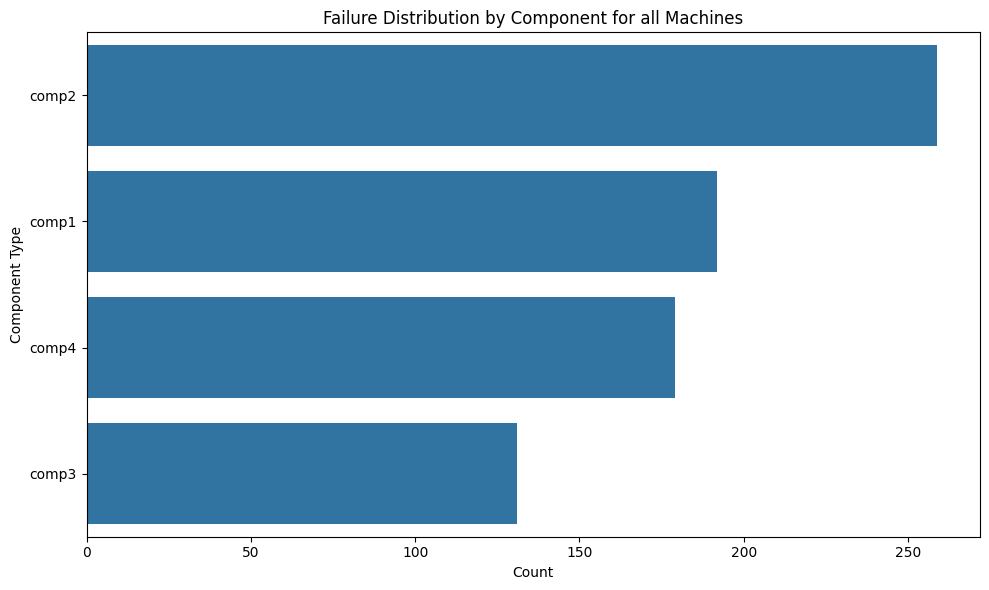

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
failure_comp_counts = failures['failure'].value_counts()
sns.barplot(x=failure_comp_counts.values, y=failure_comp_counts.index)
plt.title('Failure Distribution by Component for all Machines')
plt.xlabel('Count')
plt.ylabel('Component Type')
plt.tight_layout()
plt.savefig('focus_failure_distribution.png')

### **Telemetry patterns for each focused_machine with failures**

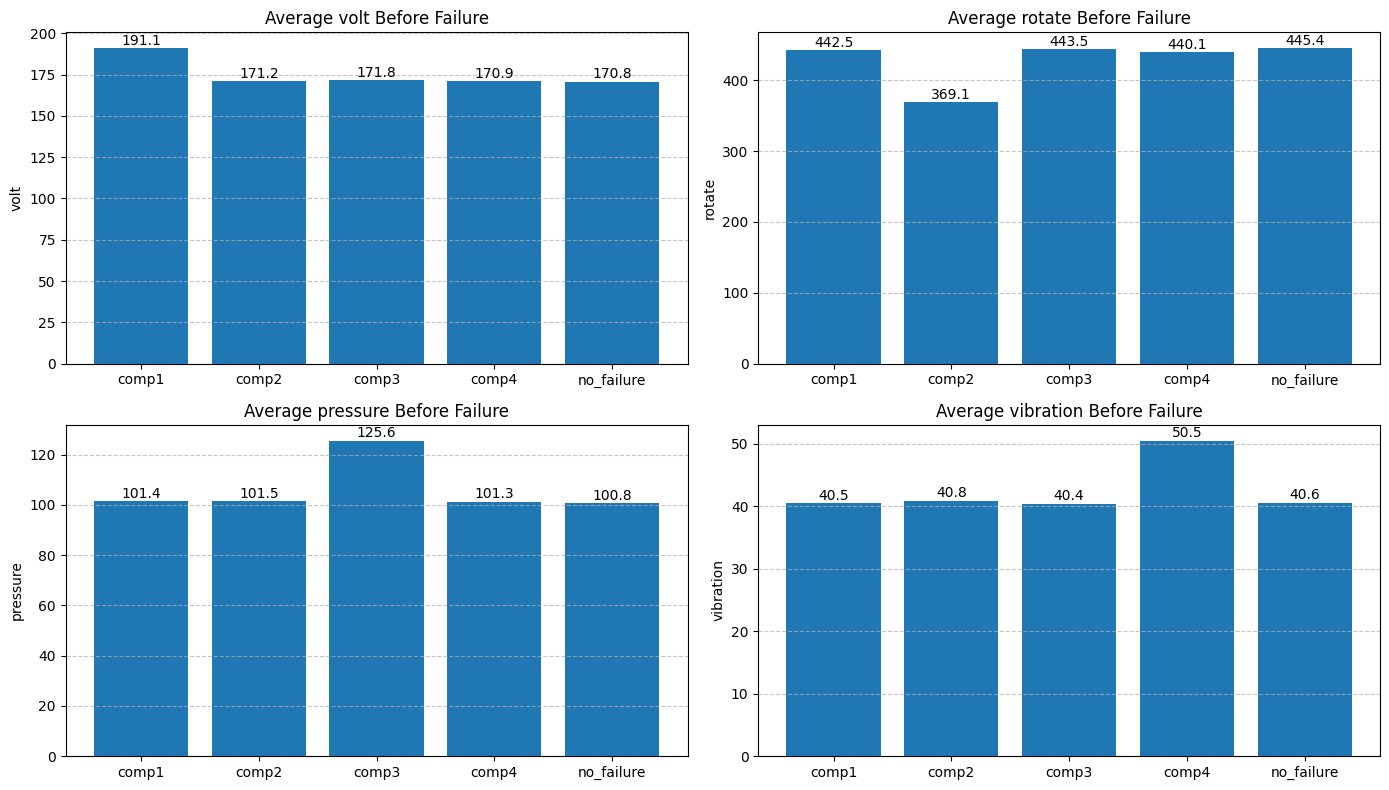

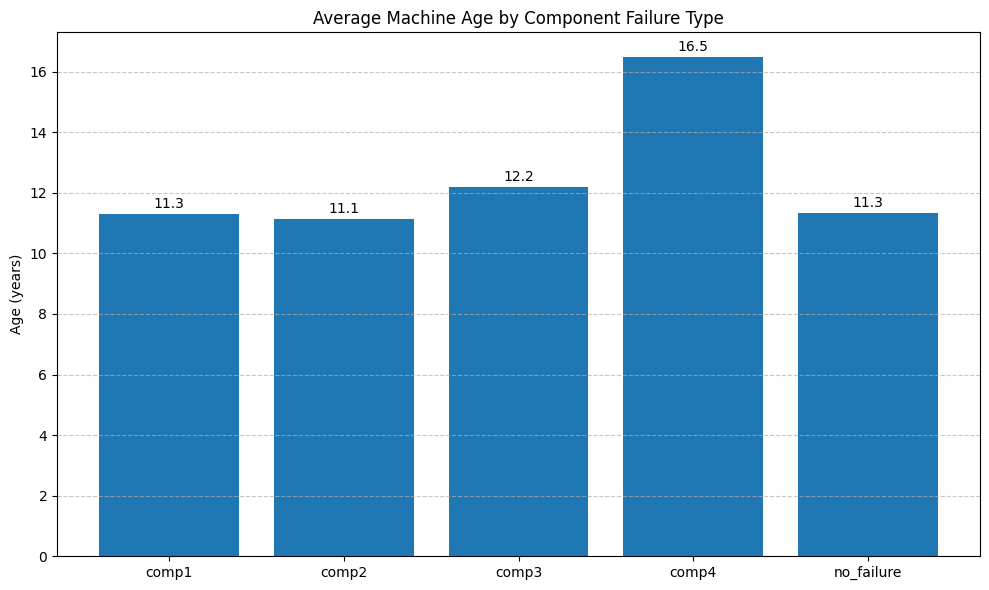

In [5]:
telemetry['date'] = telemetry['datetime'].dt.date
daily_telemetry = telemetry.groupby(['machineID', 'date']).agg({
    'volt': ['mean'],
    'rotate': ['mean'],
    'pressure': ['mean'],
    'vibration': ['mean']
}).reset_index()

daily_telemetry.columns = ['machineID', 'date', 'volt', 'rotate', 'pressure', 'vibration']
daily_telemetry = daily_telemetry.merge(machines[['machineID', 'model', 'age']], on='machineID')
failures['date'] = failures['datetime'].dt.date
failures_daily = failures[['machineID', 'date', 'failure']]
result_data = []

for component in ['comp1', 'comp2', 'comp3', 'comp4']:
    component_failures = failures_daily[failures_daily['failure'] == component]
    if len(component_failures) == 0:
        continue
    for _, failure in component_failures.iterrows():
        machine_id = failure['machineID']
        failure_date = failure['date']
        day_before = pd.Timestamp(failure_date) - pd.Timedelta(days=1)
        day_before = day_before.date()
        prev_telemetry = daily_telemetry[
            (daily_telemetry['machineID'] == machine_id) & 
            (daily_telemetry['date'] == day_before)
        ]
        if not prev_telemetry.empty:
            for _, row in prev_telemetry.iterrows():
                result_data.append({
                    'component': component,
                    'volt': row['volt'],
                    'rotate': row['rotate'],
                    'pressure': row['pressure'],
                    'vibration': row['vibration'],
                    'age': row['age'],
                    'model': row['model']
                })
failure_df = pd.DataFrame(result_data)


control_data = []
for machine_id in machines['machineID'].unique():
    machine_telemetry = daily_telemetry[daily_telemetry['machineID'] == machine_id]
    machine_failures = failures_daily[failures_daily['machineID'] == machine_id]
    failure_dates = set(machine_failures['date'])
    non_failure_dates = [date for date in machine_telemetry['date'] if date not in failure_dates] 
    sample_dates = np.random.choice(non_failure_dates, min(5, len(non_failure_dates)), replace=False)

    for date in sample_dates:
        sample_telemetry = machine_telemetry[machine_telemetry['date'] == date]
        for _, row in sample_telemetry.iterrows():
            control_data.append({
                'component': 'no_failure',
                'volt': row['volt'],
                'rotate': row['rotate'],
                'pressure': row['pressure'],
                'vibration': row['vibration'],
                'age': row['age'],
                'model': row['model']
            })
control_df = pd.DataFrame(control_data)
all_data = pd.concat([failure_df, control_df])
all_data['model_code'] = pd.Categorical(all_data['model']).codes
plt.figure(figsize=(14, 8))
components = failure_df['component'].unique()
telemetry_vars = ['volt', 'rotate', 'pressure', 'vibration']

for i, var in enumerate(telemetry_vars):
    plt.subplot(2, 2, i+1)
    means = []
    for comp in list(components) + ['no_failure']:
        if comp in all_data['component'].values:
            means.append(all_data[all_data['component'] == comp][var].mean())
        else:
            means.append(0)
    bars = plt.bar(list(components) + ['no_failure'], means)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}', ha='center', va='bottom')
    
    plt.title(f'Average {var} Before Failure')
    plt.ylabel(var)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('simple_component_telemetry.png')
plt.figure(figsize=(10, 6))

age_means = []
for comp in list(components) + ['no_failure']:
    if comp in all_data['component'].values:
        age_means.append(all_data[all_data['component'] == comp]['age'].mean())
    else:
        age_means.append(0)
bars = plt.bar(list(components) + ['no_failure'], age_means)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}', ha='center', va='bottom')

plt.title('Average Machine Age by Component Failure Type')
plt.ylabel('Age (years)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('simple_age_component.png')

### **(component vs. telemetry) & (age vs. component) failures corrrelation**

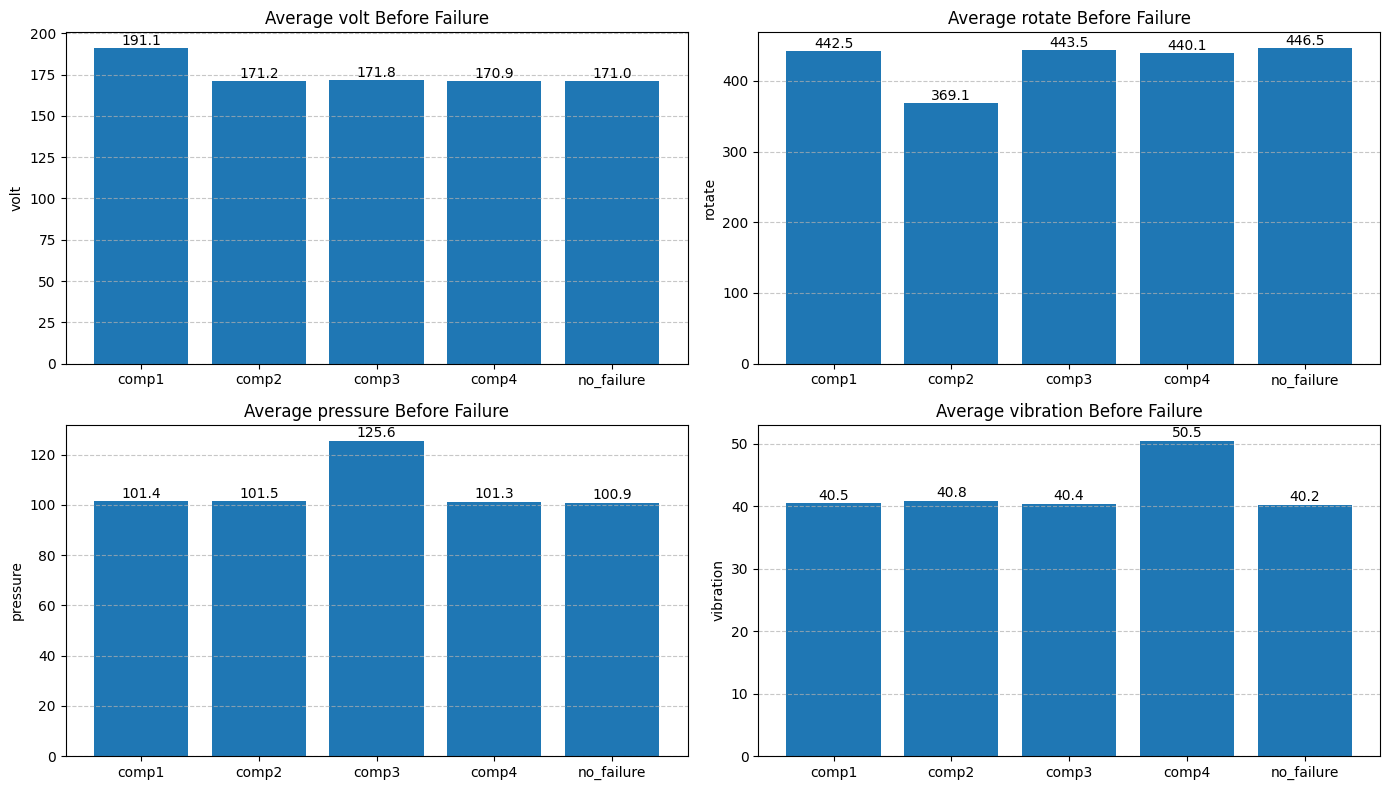

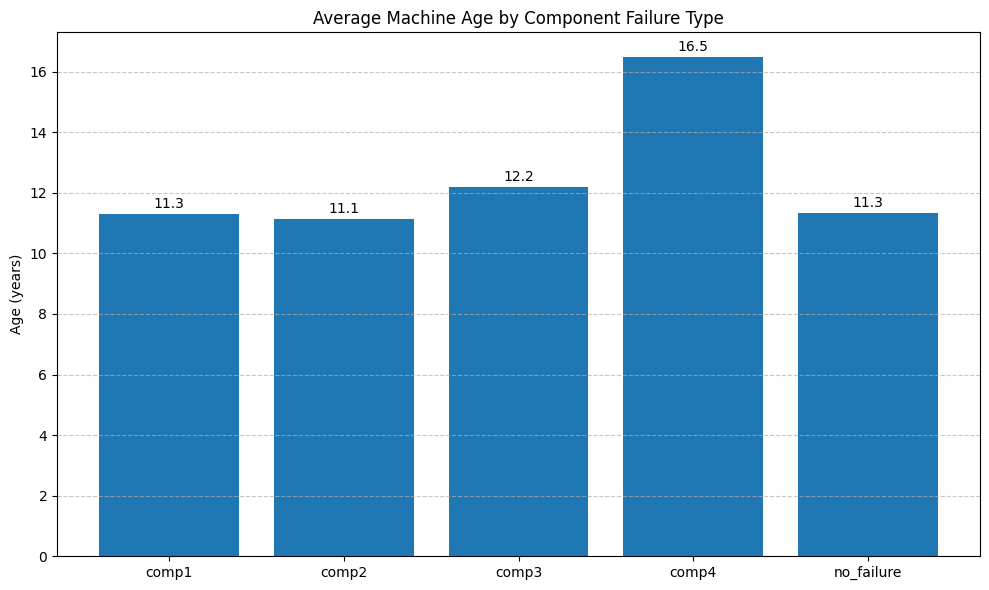

In [ ]:
telemetry['date'] = telemetry['datetime'].dt.date
daily_telemetry = telemetry.groupby(['machineID', 'date']).agg({
    'volt': ['mean'],
    'rotate': ['mean'],
    'pressure': ['mean'],
    'vibration': ['mean']
}).reset_index()

daily_telemetry.columns = ['machineID', 'date', 'volt', 'rotate', 'pressure', 'vibration']
daily_telemetry = daily_telemetry.merge(machines[['machineID', 'model', 'age']], on='machineID')
failures['date'] = failures['datetime'].dt.date
failures_daily = failures[['machineID', 'date', 'failure']]
result_data = []

for component in ['comp1', 'comp2', 'comp3', 'comp4']:
    component_failures = failures_daily[failures_daily['failure'] == component]
    if len(component_failures) == 0:
        continue
    for _, failure in component_failures.iterrows():
        machine_id = failure['machineID']
        failure_date = failure['date'] 
        day_before = pd.Timestamp(failure_date) - pd.Timedelta(days=1)
        day_before = day_before.date()
        prev_telemetry = daily_telemetry[
            (daily_telemetry['machineID'] == machine_id) & 
            (daily_telemetry['date'] == day_before)
        ]
        if not prev_telemetry.empty:
            for _, row in prev_telemetry.iterrows():
                result_data.append({
                    'component': component,
                    'volt': row['volt'],
                    'rotate': row['rotate'],
                    'pressure': row['pressure'],
                    'vibration': row['vibration'],
                    'age': row['age'],
                    'model': row['model']
                })

failure_df = pd.DataFrame(result_data)

control_data = []
for machine_id in machines['machineID'].unique():
    machine_telemetry = daily_telemetry[daily_telemetry['machineID'] == machine_id]
    machine_failures = failures_daily[failures_daily['machineID'] == machine_id]
    failure_dates = set(machine_failures['date'])
    non_failure_dates = [date for date in machine_telemetry['date'] if date not in failure_dates]
    sample_dates = np.random.choice(non_failure_dates, min(5, len(non_failure_dates)), replace=False)
    
    for date in sample_dates:
        sample_telemetry = machine_telemetry[machine_telemetry['date'] == date]
        for _, row in sample_telemetry.iterrows():
            control_data.append({
                'component': 'no_failure',
                'volt': row['volt'],
                'rotate': row['rotate'],
                'pressure': row['pressure'],
                'vibration': row['vibration'],
                'age': row['age'],
                'model': row['model']
            })

control_df = pd.DataFrame(control_data)
all_data = pd.concat([failure_df, control_df])
all_data['model_code'] = pd.Categorical(all_data['model']).codes
plt.figure(figsize=(14, 8))
components = failure_df['component'].unique()
telemetry_vars = ['volt', 'rotate', 'pressure', 'vibration']

for i, var in enumerate(telemetry_vars):
    plt.subplot(2, 2, i+1)
    means = []
    for comp in list(components) + ['no_failure']:
        if comp in all_data['component'].values:
            means.append(all_data[all_data['component'] == comp][var].mean())
        else:
            means.append(0)
    bars = plt.bar(list(components) + ['no_failure'], means)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}', ha='center', va='bottom')
    plt.title(f'Average {var} Before Failure')
    plt.ylabel(var)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('component_telemetry.png')
plt.figure(figsize=(10, 6))

age_means = []
for comp in list(components) + ['no_failure']:
    if comp in all_data['component'].values:
        age_means.append(all_data[all_data['component'] == comp]['age'].mean())
    else:
        age_means.append(0)
bars = plt.bar(list(components) + ['no_failure'], age_means)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}', ha='center', va='bottom')

plt.title('Average Machine Age by Component Failure Type')
plt.ylabel('Age (years)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('age_component.png')

### **summarize**

> Component 1
>> Right before it fails, its voltage spikes above normal operating levels—suggesting (**an electrical over‑stress**).

> Component 2
>> Its rotational speed drops significantly prior to failure—often indicating (**the machine is being overloaded**).

> Component 3
>> You’ll see a steady rise in pressure immediately before a fault.

> Component 4
>> Just before failure, vibration levels climb (**sharply—consistent with rotor imbalance**) in that mechanical assembly.

# **3. FEATURE ENGINEERING**

In [7]:
def create_features(machine_id, telemetry_df, errors_df, maint_df, failures_df, machines_df):
    machine_telemetry = telemetry_df[telemetry_df['machineID'] == machine_id].copy()
    machine_errors = errors_df[errors_df['machineID'] == machine_id].copy()
    machine_maint = maint_df[maint_df['machineID'] == machine_id].copy()
    machine_failures = failures_df[failures_df['machineID'] == machine_id].copy()
    machine_info = machines_df[machines_df['machineID'] == machine_id]

    if machine_telemetry.empty:
        return pd.DataFrame()

    result_df = machine_telemetry.copy()
    result_df['model'] = machine_info['model'].values[0]
    result_df['age'] = machine_info['age'].values[0]

    window = 12
    for col in ['volt', 'rotate', 'pressure', 'vibration']:
        result_df[f'{col}_mean_12h'] = result_df[col].rolling(window=window, min_periods=1).mean()
        result_df[f'{col}_std_12h'] = result_df[col].rolling(window=window, min_periods=1).std()

    result_df['has_errors_12h'] = 0
    for idx, row in result_df.iterrows():
        window_start = row['datetime'] - timedelta(hours=12)
        error_count = machine_errors[(machine_errors['datetime'] > window_start) & (machine_errors['datetime'] < row['datetime'])].shape[0]
        if error_count > 0:
            result_df.at[idx, 'has_errors_12h'] = 1

    result_df['has_maintenance_7d'] = 0
    for idx, row in result_df.iterrows():
        window_start = row['datetime'] - timedelta(days=7)
        maint_count = machine_maint[(machine_maint['datetime'] > window_start) & (machine_maint['datetime'] < row['datetime'])].shape[0]
        if maint_count > 0:
            result_df.at[idx, 'has_maintenance_7d'] = 1

    result_df['failure_within_24h'] = 0
    for _, failure in machine_failures.iterrows():
        failure_time = failure['datetime']
        window_start = failure_time - timedelta(hours=24)
        window_end = failure_time - timedelta(minutes=5)
        window_mask = (result_df['datetime'] >= window_start) & (result_df['datetime'] <= window_end)
        result_df.loc[window_mask, 'failure_within_24h'] = 1

    result_df = result_df.fillna(0)
    return result_df


In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pickle

models_results = {}

# **3. DATA PREPARATION FOR MODELING**

In [ ]:
def prepare_modeling_data_chronological(data, target_col='failure_within_24h', test_fraction=0.20):

    data_sorted = data.sort_values('datetime')
    split_idx = int(len(data_sorted) * (1 - test_fraction))
    split_date = data_sorted.iloc[split_idx]['datetime']
    print(f"Train-test split date: {split_date}")

    train_data = data_sorted[data_sorted['datetime'] < split_date]
    test_data = data_sorted[data_sorted['datetime'] >= split_date]

    X_train = train_data.drop(['datetime', 'machineID', target_col, 'model'], axis=1)
    y_train = train_data[target_col]

    X_test = test_data.drop(['datetime', 'machineID', target_col, 'model'], axis=1)
    y_test = test_data[target_col]

    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = 0

    X_test = X_test[X_train.columns]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test, X_train.columns

print("Starting improved predictive maintenance pipeline...")
focus_machines = enhanced_failure_counts['machineID'].values[[2, 13, 16]]
print(f"Selected focus machines: {focus_machines}")

all_machine_features = []

for machine_id in focus_machines:
    print(f"Generating simplified features for machine {machine_id}...")
    machine_features = create_features(machine_id, telemetry, errors, maint, failures, machines)
    if not machine_features.empty:
        all_machine_features.append(machine_features)
simplified_data = pd.concat(all_machine_features, ignore_index=True)

print(f"Feature engineering complete. Using {simplified_data.shape[1]} columns (reduced set)")

X_train, X_test, y_train, y_test, feature_names = prepare_modeling_data_chronological(simplified_data)
minority_count = y_train.sum()

print(f"Failure samples in training: {minority_count} ({minority_count/len(y_train)*100:.2f}%)")

if minority_count >= 5 and minority_count/len(y_train) < 0.2:
    smote = SMOTE(random_state=42, sampling_strategy=min(0.3, minority_count/len(y_train)*2))
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"Applied conservative SMOTE: {y_train_resampled.mean()*100:.2f}% positive class")
else:
    X_train_resampled, y_train_resampled = X_train, y_train
    print("Using original class balance")

Starting improved predictive maintenance pipeline...
Selected focus machines: [99 98 22]
Generating simplified features for machine 99...
Generating simplified features for machine 98...
Generating simplified features for machine 22...
Feature engineering complete. Using 20 columns (reduced set)
Train-test split date: 2015-10-20 06:00:00
Failure samples in training: 930 (4.42%)
Applied conservative SMOTE: 8.12% positive class


# **5. MODEL TRAINING AND EVALUATION**

### **1. RANDOM FOREST MODEL**


----- RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=8,
                       min_samples_split=10, n_estimators=50, n_jobs=-1,
                       random_state=42) Evaluation -----
Accuracy: 0.9190
ROC AUC: 0.9779
PR AUC: 0.6346

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      5091
           1       0.28      0.95      0.43       168

    accuracy                           0.92      5259
   macro avg       0.64      0.93      0.69      5259
weighted avg       0.98      0.92      0.94      5259



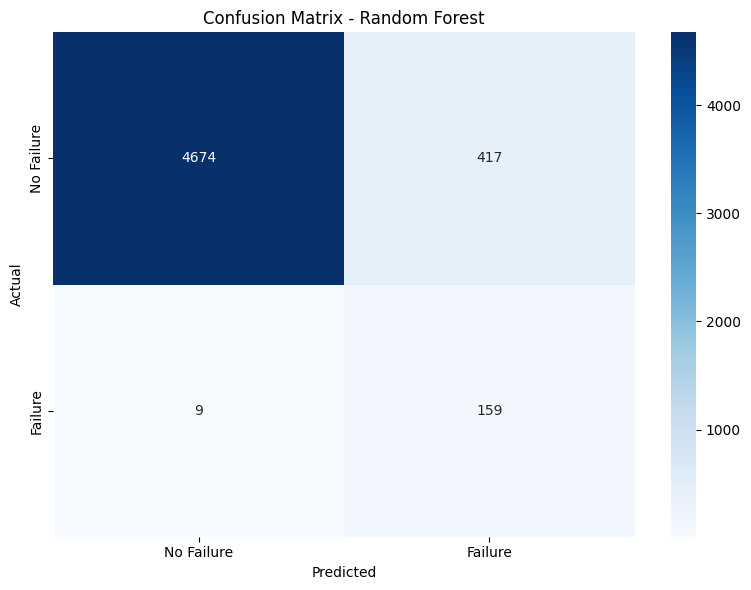

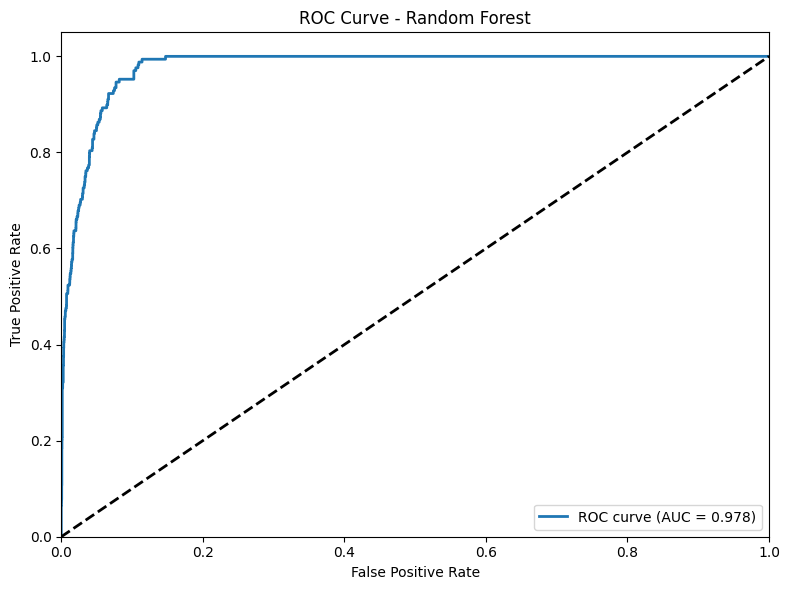

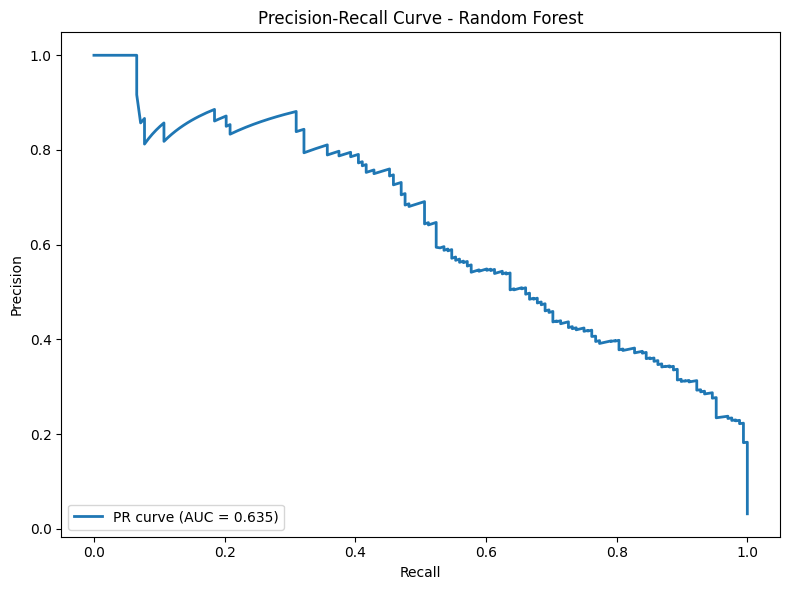

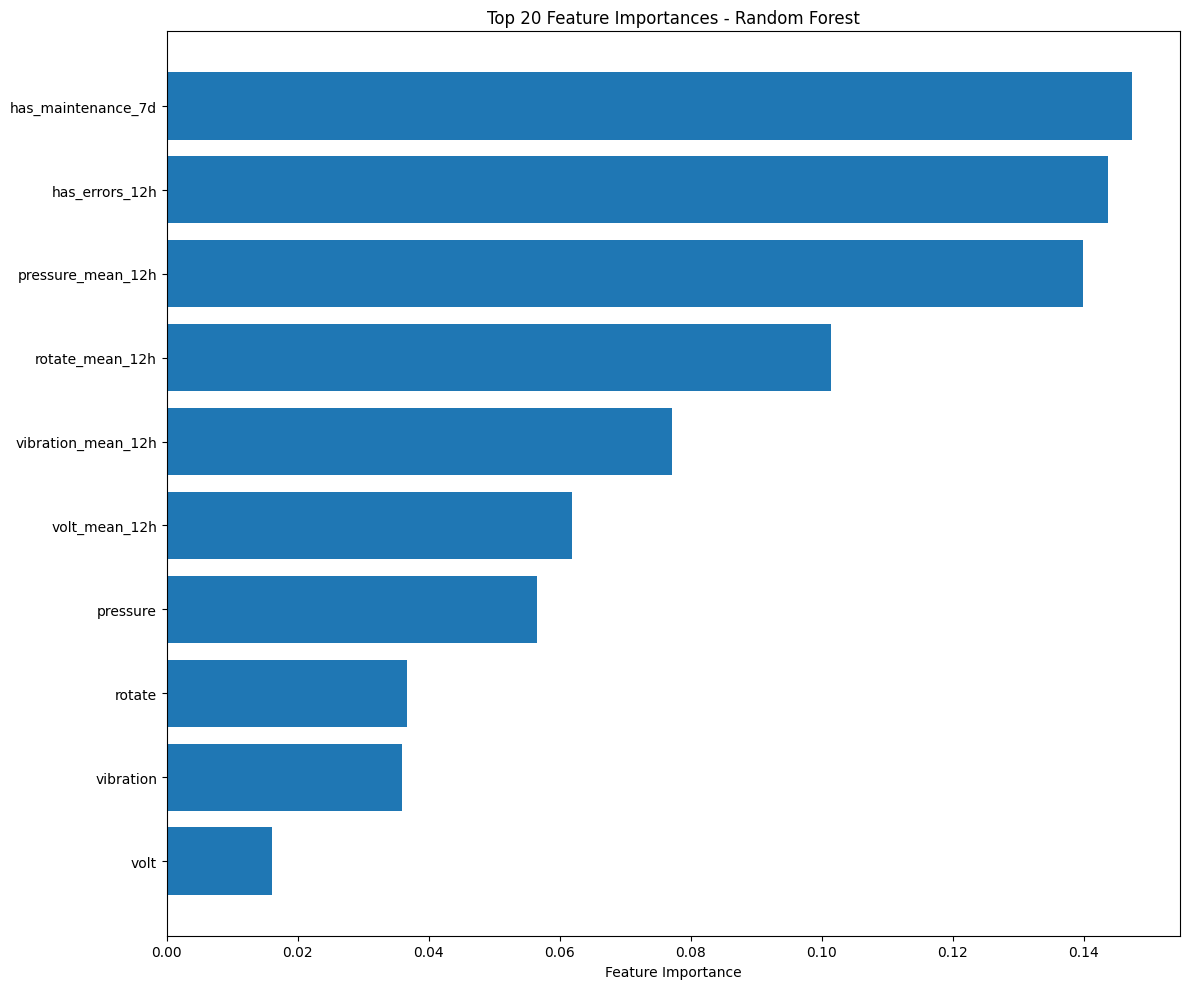

In [ ]:
def evaluate_random_forest(X_train, y_train, X_test, y_test, feature_names, threshold=0.5):

    model = RandomForestClassifier(n_estimators=100,
                                   max_depth=6,
                                   min_samples_leaf=8,
                                   min_samples_split=10,
                                   max_features='sqrt',
                                   class_weight='balanced',
                                   random_state=42,
                                   n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    print(f"\n----- {model} Evaluation -----")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"\nClassification Report (threshold={threshold}):")
    print(report)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Random Forest')
    plt.tight_layout()
    plt.savefig('confusion_matrix_random_forest.png')

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Random Forest')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('roc_curve_random_forest.png')

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve - Random Forest')
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig('pr_curve_random_forest.png')

    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    plt.figure(figsize=(12, 10))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances - Random Forest')
    plt.tight_layout()
    plt.savefig('feature_importance_random_forest.png')

    return model, {'accuracy': accuracy, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

rf_model, rf_metrics = evaluate_random_forest(X_train_resampled, y_train_resampled, X_test, y_test, feature_names)
models_results["Random Forest"] = rf_metrics


### **2. GRADIENT BOOSTING MODEL**


Training Gradient Boosting model...

----- Gradient Boosting Evaluation -----
Accuracy: 0.9760
ROC AUC: 0.9780
PR AUC: 0.6650

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5091
           1       0.71      0.42      0.53       168

    accuracy                           0.98      5259
   macro avg       0.85      0.71      0.76      5259
weighted avg       0.97      0.98      0.97      5259



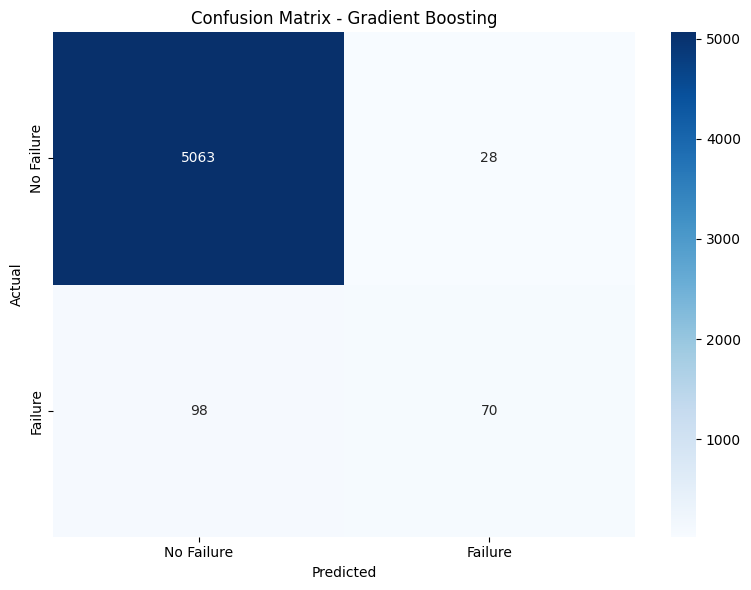

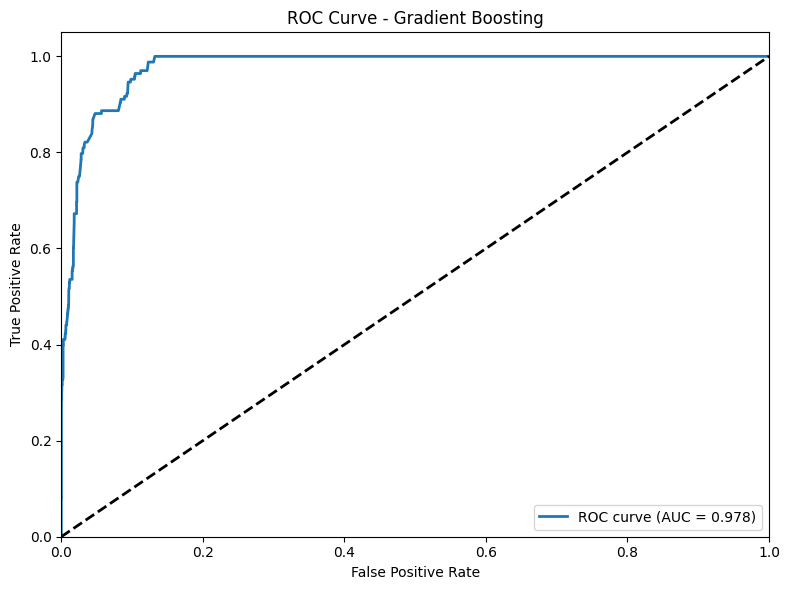

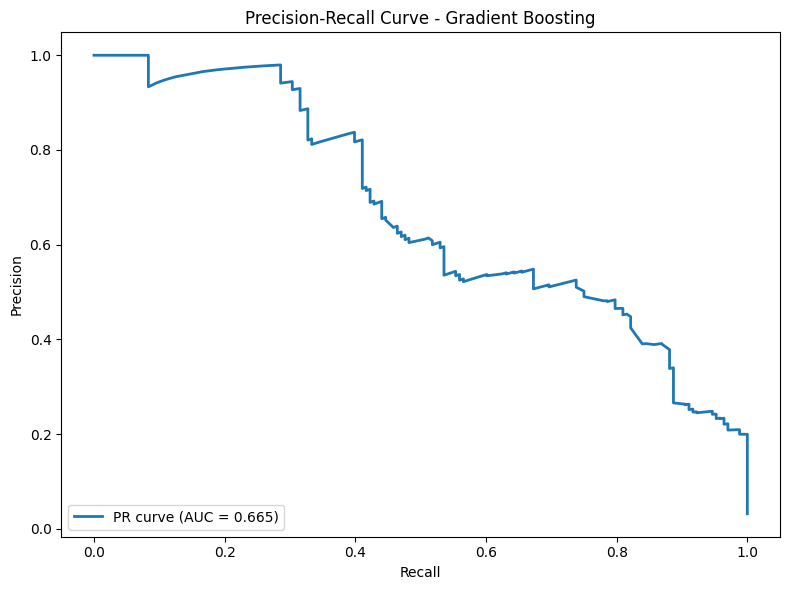

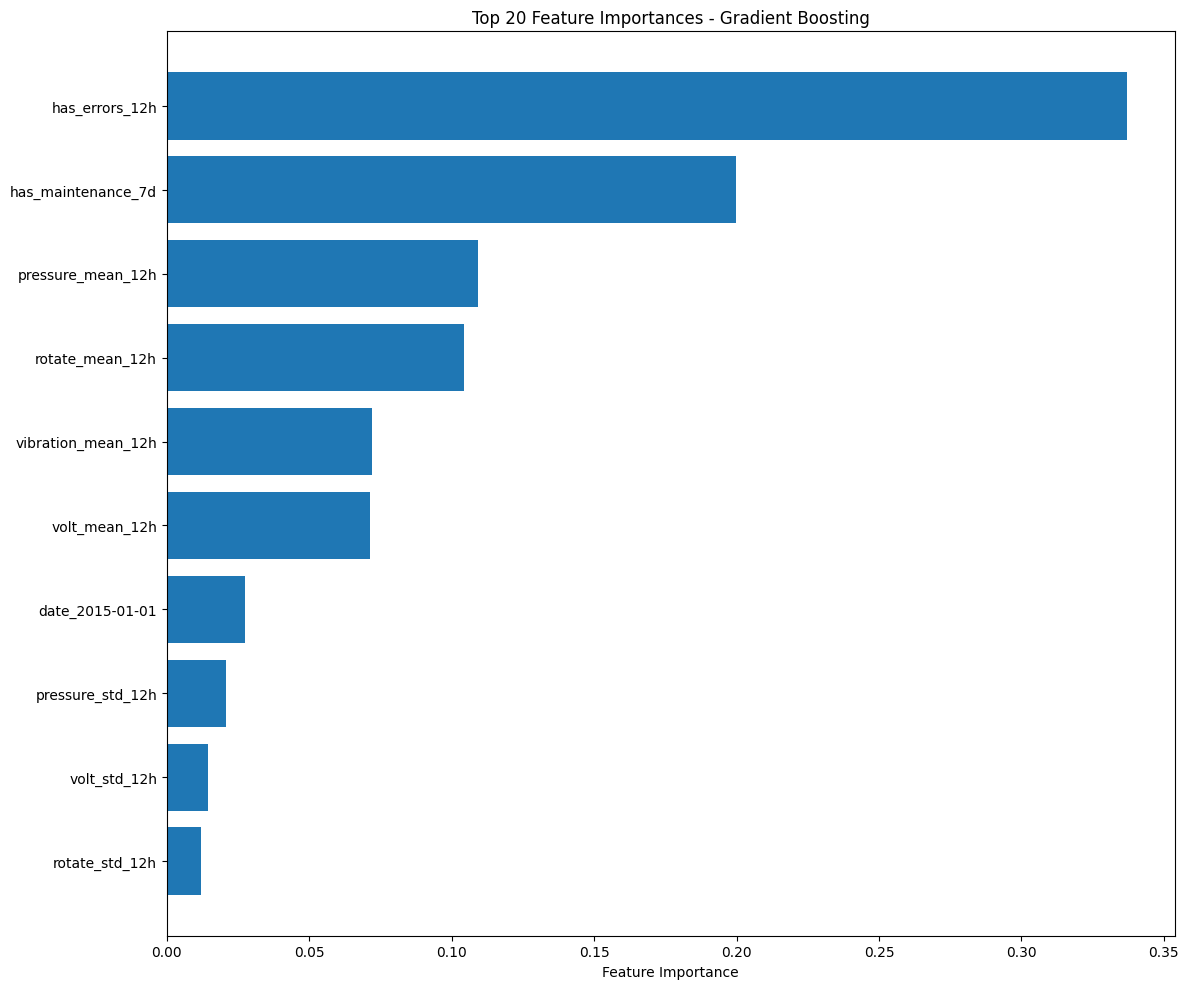

In [ ]:
def evaluate_gradient_boosting(X_train, y_train, X_test, y_test, feature_names, threshold=0.5):
    
    model_name = "Gradient Boosting"
    print(f"\nTraining {model_name} model...")

    model = GradientBoostingClassifier(n_estimators=50,
                                        learning_rate=0.05,
                                        max_depth=4,
                                        min_samples_leaf=10,
                                        subsample=0.8,
                                        random_state=42)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    print(f"\n----- {model} Evaluation -----")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"\nClassification Report (threshold={threshold}):")
    print(report)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_gradient_boosting.png')
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f'roc_curve_gradient_boosting.png')
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(f'pr_curve_gradient_boosting.png')
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    
    plt.figure(figsize=(12, 10))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importances - {model_name}')
    plt.tight_layout()
    plt.savefig(f'feature_importance_gradient_boosting.png')
    
    return model, {'accuracy': accuracy, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

gb_model, gb_metrics = evaluate_gradient_boosting(
    X_train_resampled, y_train_resampled, X_test, y_test, feature_names
)
models_results["Gradient Boosting"] = gb_metrics

### **3. XGBOOST MODEL**


Training XGBoost model...

----- XGBoost Evaluation -----
Accuracy: 0.9768
ROC AUC: 0.9782
PR AUC: 0.6713

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5091
           1       0.73      0.43      0.54       168

    accuracy                           0.98      5259
   macro avg       0.86      0.71      0.77      5259
weighted avg       0.97      0.98      0.97      5259



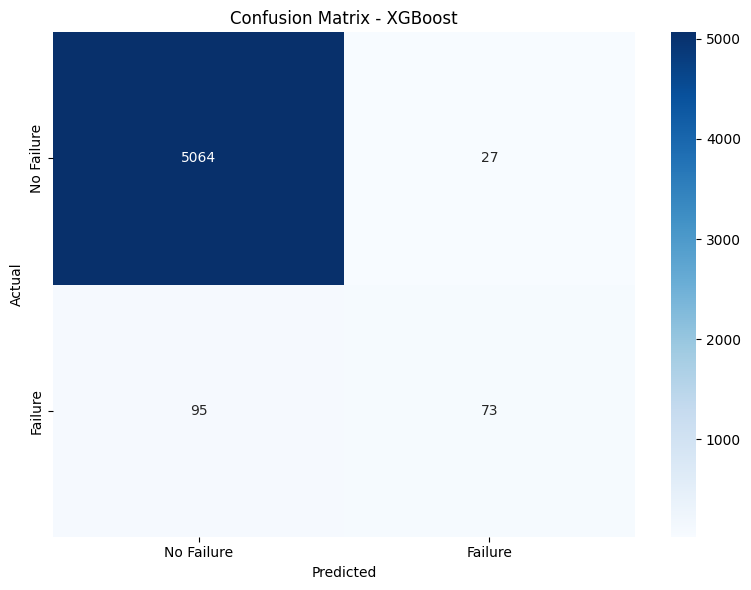

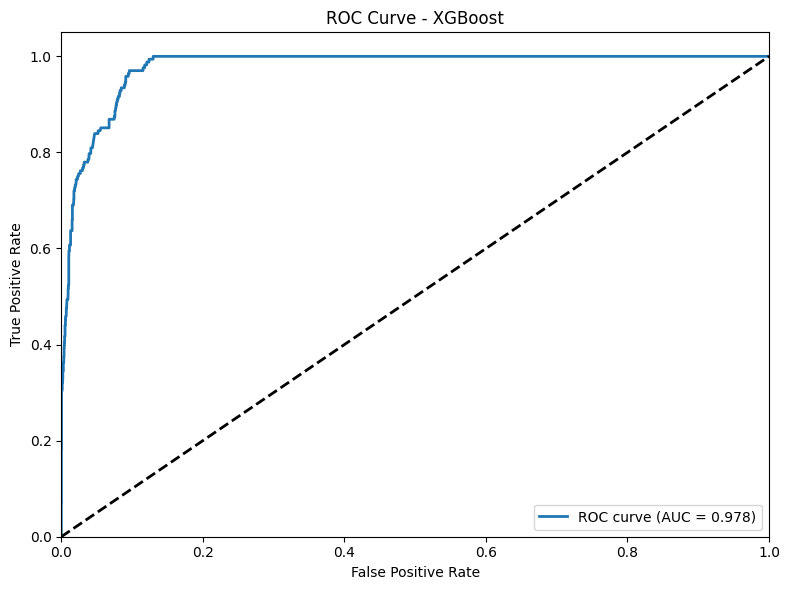

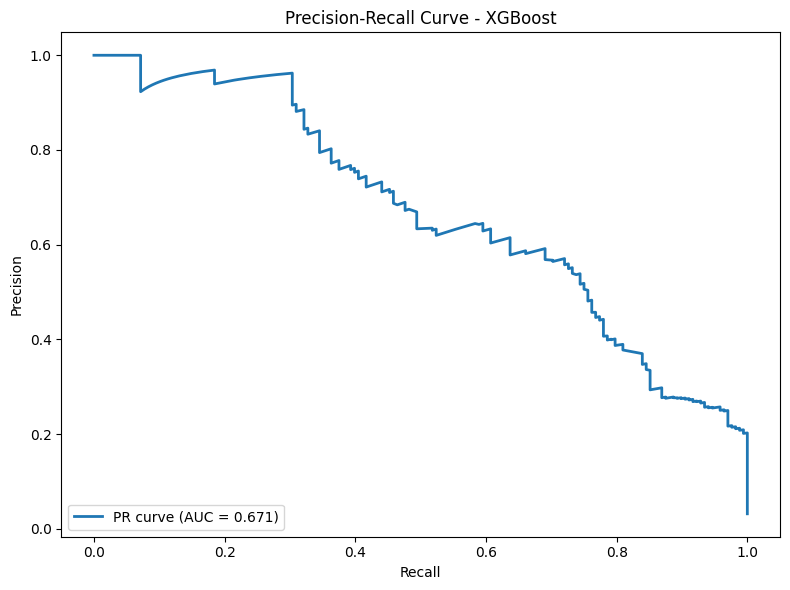

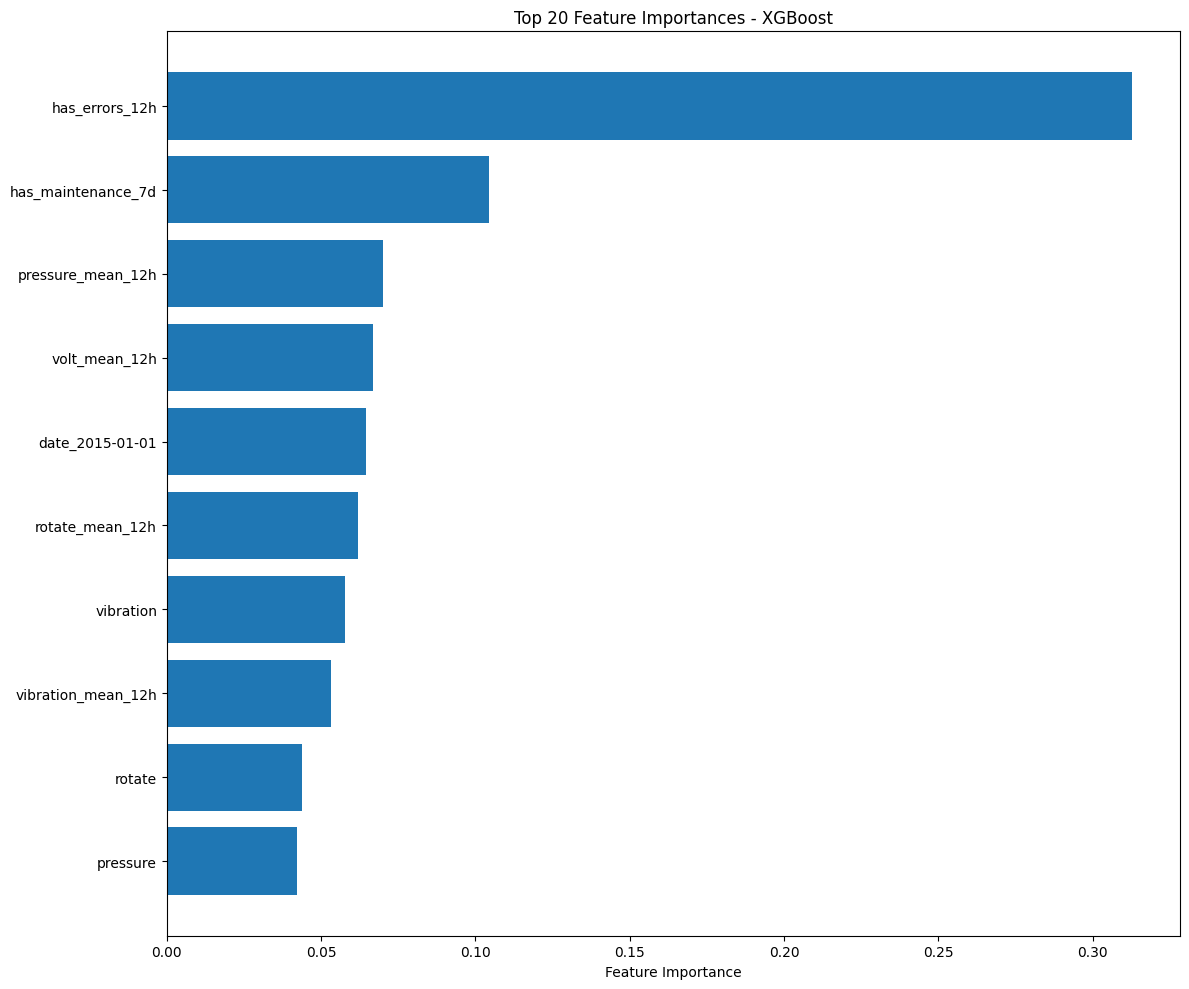

In [ ]:
def evaluate_xgboost(X_train, y_train, X_test, y_test, feature_names, threshold=0.5):
    
    model = "XGBoost"
    print(f"\nTraining {model} model...")
    
    model = XGBClassifier(n_estimators=50,
                          learning_rate=0.05,
                          max_depth=4,
                          min_child_weight=5,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          gamma=1,
                          random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss')
    
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    print(f"\n----- {model} Evaluation -----")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"\nClassification Report (threshold={threshold}):")
    print(report)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_xgboost.png')
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f'roc_curve_xgboost.png')
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model}')
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(f'pr_curve_xgboost.png')
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    
    plt.figure(figsize=(12, 10))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importances - {model}')
    plt.tight_layout()
    plt.savefig(f'feature_importance_xgboost.png')
    
    return model, {'accuracy': accuracy, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

xgb_model, xgb_metrics = evaluate_xgboost(
    X_train_resampled, y_train_resampled, X_test, y_test, feature_names
)
models_results["XGBoost"] = xgb_metrics

### **Identify best model based on PR AUC**


Best model: XGBoost with PR AUC: 0.6713


<Figure size 1000x600 with 0 Axes>

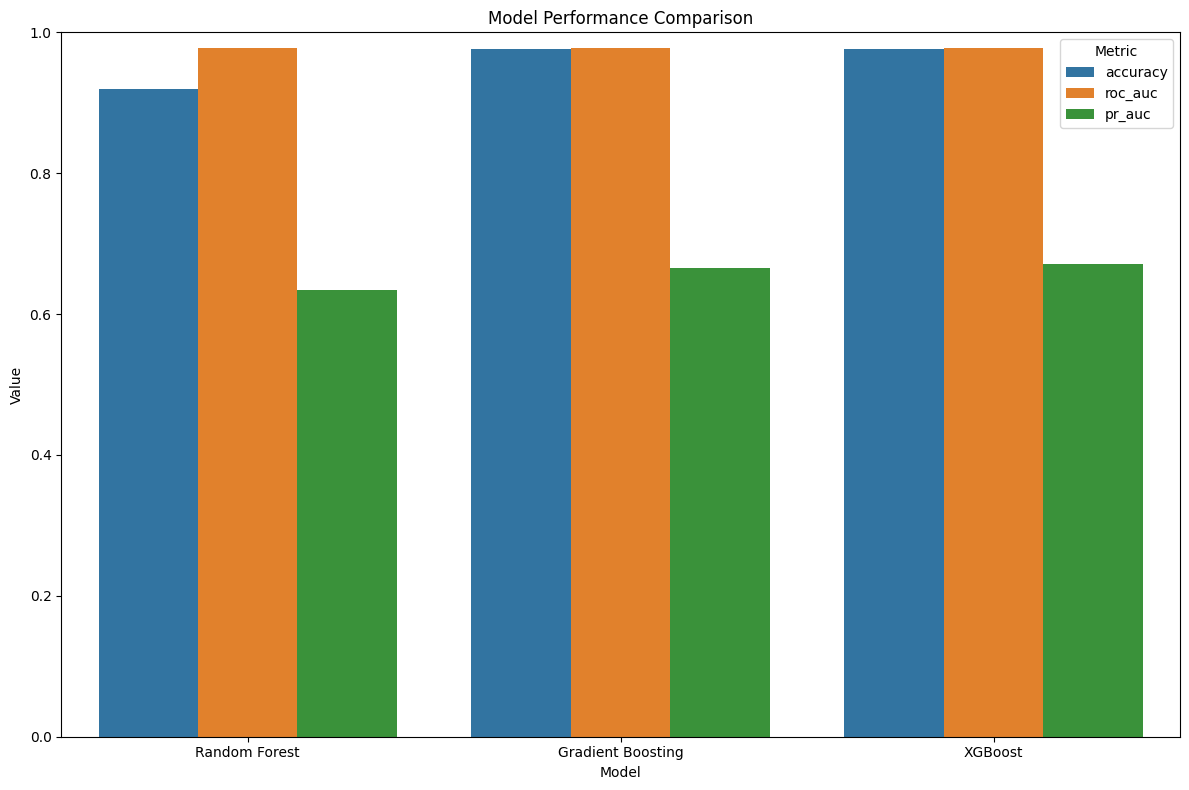

In [18]:
best_model_name = max(models_results, key=lambda k: models_results[k]['pr_auc'])

if best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "Gradient Boosting":
    best_model = gb_model
elif best_model_name == "XGBoost":
    best_model = xgb_model

print(f"\nBest model: {best_model_name} with PR AUC: {models_results[best_model_name]['pr_auc']:.4f}")

plt.figure(figsize=(10, 6))
metrics_df = pd.DataFrame(models_results).T
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

plt.figure(figsize=(12, 8))
metrics_df_melted = pd.melt(metrics_df, id_vars=['Model'], var_name='Metric', value_name='Value')
sns.barplot(x='Model', y='Value', hue='Metric', data=metrics_df_melted)
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison.png')